In [ ]:
!pip install pykml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.1/41.1 kB 2.2 MB/s eta 0:00:00


In [13]:
## --------------- INTEGRACION Y TABLA ---------------- #
import pandas as pd
import numpy as np

# A. CARGA DE LOS 3 DATASETS
# Asegúrate de haber subido estos archivos a la carpeta lateral de Colab
df_clima = pd.read_csv('NuevoLeon_clima.csv')
df_rad = pd.read_csv('NuevoLeon_radiacion.csv')
df_contam = pd.read_csv('NuevoLeon_contaminantes.csv')

# B. PREPARACIÓN DE FORMATOS
# Convertimos la columna de fecha a tipo datetime para que el merge sea preciso
df_clima['PERIODO'] = pd.to_datetime(df_clima['PERIODO'])
df_rad['PERIODO'] = pd.to_datetime(df_rad['PERIODO'])
df_contam['PERIODO'] = pd.to_datetime(df_contam['PERIODO'])

# C. INTEGRACIÓN (EL "JUNTE" DE ARCHIVOS)
# Unimos Clima con Radiación usando Fecha y Estación como anclas
df_unido = pd.merge(df_clima, df_rad, on=['PERIODO', 'ESTACION'], how='inner')

# Unimos el resultado anterior con Contaminantes
df_final = pd.merge(df_unido, df_contam, on=['PERIODO', 'ESTACION'], how='inner')

# D. LIMPIEZA Y ORDENAMIENTO
# Ordenamos por estación y luego por fecha para que las series de tiempo tengan sentido
df_final = df_final.sort_values(by=['ESTACION', 'PERIODO']).reset_index(drop=True)

# E. VARIABLE OBJETIVO
# Binarizamos: 1 si llovió, 0 si no
df_final['LLUVIA_BIN'] = (df_final['PRECIPITACION'] > 0).astype(int)

# =========================================================
# LA LÍNEA QUE CREA EL ARCHIVO CSV:
# =========================================================
df_final.to_csv('Dataset_Final_NuevoLeon.csv', index=False)

print("✅ ¡El archivo 'Dataset_Final_NuevoLeon.csv' ha sido creado!")


print(f"✅ Integración completada con éxito.")
print(f"Número total de registros integrados: {len(df_final)}")
print(f"Número de estaciones integradas: {df_final['ESTACION'].nunique()}")
display(df_final.head())

✅ ¡El archivo 'Dataset_Final_NuevoLeon.csv' ha sido creado!
✅ Integración completada con éxito.
Número total de registros integrados: 2640
Número de estaciones integradas: 20


,PERIODO,ESTACION,PRECIPITACION,MEDIA,MINIMA,MAXIMA,RADIACION,PM10,PM25,LLUVIA_BIN
0,2011-01-01,APODACA (DGE),0.780244,12.485514,7.485514,17.485514,185.284584,54.506034,15.650918,1
1,2011-01-02,APODACA (DGE),0.000000,17.433722,12.433722,22.433722,190.487104,37.905231,26.944894,0
2,2011-01-03,APODACA (DGE),0.000000,21.611462,16.611462,26.611462,208.663128,60.487071,33.277036,0
3,2011-01-04,APODACA (DGE),2.746578,24.775666,19.775666,29.775666,252.368115,46.419706,24.303014,1
4,2011-01-05,APODACA (DGE),41.094797,25.109491,20.109491,30.109491,283.075805,50.726805,22.942534,1


/tmp/ipython-input-165/1649687610.py:33: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[['PRECIPITACION', 'RADIACION', 'PM10', 'PM25']] = df.groupby('ESTACION')[['PRECIPITACION', 'RADIACION', 'PM10', 'PM25']].transform(lambda x: x.interpolate().fillna(method='bfill'))
/tmp/ipython-input-165/1649687610.py:33: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[['PRECIPITACION', 'RADIACION', 'PM10', 'PM25']] = df.groupby('ESTACION')[['PRECIPITACION', 'RADIACION', 'PM10', 'PM25']].transform(lambda x: x.interpolate().fillna(method='bfill'))
/tmp/ipython-input-165/1649687610.py:33: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[['PRECIPITACION', 'RADIACION', 'PM10', 'PM25']] = df.groupby('ESTACION')[['PRECIPITACION', 'RAD

✅ Integración exitosa.
Total de estaciones: 20
Columnas finales: ['PERIODO', 'ESTACION', 'PRECIPITACION', 'MEDIA', 'MINIMA', 'MAXIMA', 'RADIACION', 'PM10', 'PM25', 'radiacion_lag1', 'LLUVIA_BIN']


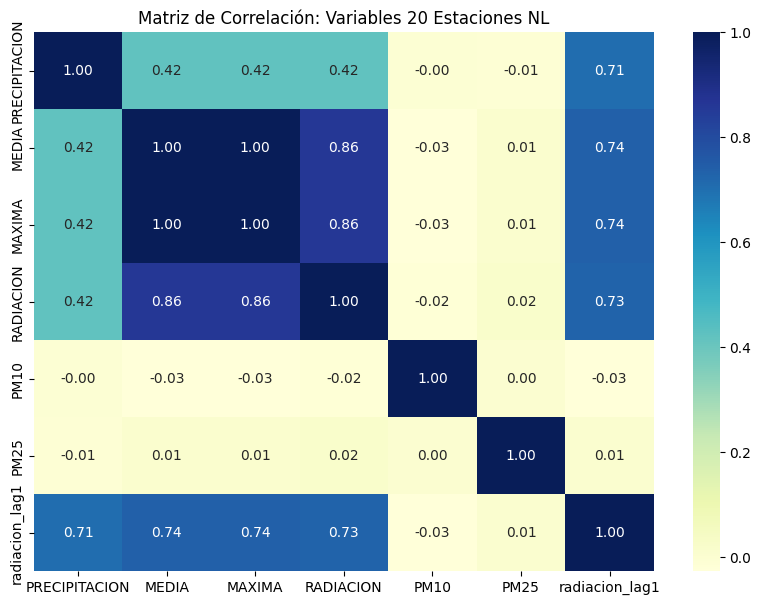

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1. CARGA DE DATOS
try:
    # Cargamos los archivos de las 20 estaciones
    df_clima = pd.read_csv('NuevoLeon_clima.csv')
    df_rad = pd.read_csv('NuevoLeon_radiacion.csv')
    df_contam = pd.read_csv('NuevoLeon_contaminantes.csv')

    # Asegurar formato de fecha y quitar espacios en blanco en nombres de estaciones
    for df_temp in [df_clima, df_rad, df_contam]:
        df_temp['PERIODO'] = pd.to_datetime(df_temp['PERIODO'])
        if 'ESTACION' in df_temp.columns:
            df_temp['ESTACION'] = df_temp['ESTACION'].str.strip()


    # ---------2. INTEGRACIÓN (Fusión exacta por Fecha y Estación)---------- #
    # Primero Clima con Radiación
    df = pd.merge(df_clima, df_rad, on=['PERIODO', 'ESTACION'], how='inner')
    # Luego el resultado con Contaminantes
    df = pd.merge(df, df_contam, on=['PERIODO', 'ESTACION'], how='inner')

    # Ordenar para que el historial de cada estación sea continuo
    df = df.sort_values(by=['ESTACION', 'PERIODO']).reset_index(drop=True)


    # --------------3. MANEJO DE GAPS E INGENIERÍA------------- #
    # Interpolación: Rellena huecos solo dentro de la misma estación
    df[['PRECIPITACION', 'RADIACION', 'PM10', 'PM25']] = df.groupby('ESTACION')[['PRECIPITACION', 'RADIACION', 'PM10', 'PM25']].transform(lambda x: x.interpolate().fillna(method='bfill'))

    # Crear Lag (retraso) de radiación por estación
    df['radiacion_lag1'] = df.groupby('ESTACION')['RADIACION'].shift(1)

    # Variable Objetivo: Binarización (1 si llovió más de 0.1 mm)
    df['LLUVIA_BIN'] = (df['PRECIPITACION'] > 0.1).astype(int)

    # Eliminar filas con NaN (como el primer mes de cada estación por el lag)
    df = df.dropna().reset_index(drop=True)

    print(f"✅ Integración exitosa.")
    print(f"Total de estaciones: {df['ESTACION'].nunique()}")
    print(f"Columnas finales: {df.columns.tolist()}")

except Exception as e:
    print(f"❌ Error detectado: {e}")

# ---------------------4. EDA: Visualización de Correlación---------------------- #
plt.figure(figsize=(10, 7))
# Solo columnas numéricas para el heatmap
cols_pcp = ['PRECIPITACION', 'MEDIA', 'MAXIMA', 'RADIACION', 'PM10', 'PM25', 'radiacion_lag1']
sns.heatmap(df[cols_pcp].corr(), annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Matriz de Correlación: Variables 20 Estaciones NL')
plt.show()

✅ Preprocesamiento listo. Entrenamiento: 2096 filas | Prueba: 524 filas.


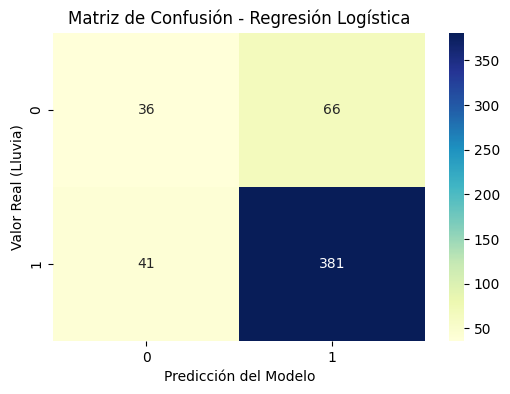

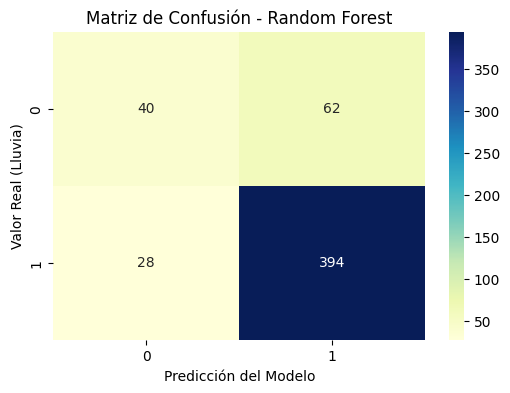

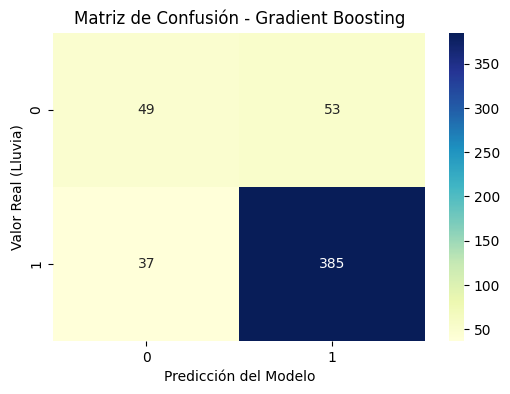


--- COMPARATIVA DE DESEMPEÑO EN NUEVO LEÓN ---


,Modelo,Accuracy,F1-Score,AUC-ROC
1,Random Forest,0.828244,0.897494,0.838479
2,Gradient Boosting,0.828244,0.895349,0.847900
0,Regresión Logística,0.795802,0.876870,0.834356


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. PREPROCESAMIENTO: ESCALAMIENTO Y SPLIT TEMPORAL
# ==========================================
# Seleccionamos las variables predictoras (X) y el objetivo (y)
features = ['MINIMA', 'MEDIA', 'MAXIMA', 'RADIACION', 'PM10', 'PM25', 'radiacion_lag1']
X = df[features]
y = df['LLUVIA_BIN']

# DIVISIÓN TEMPORAL (80% Entrenamiento / 20% Prueba)
# Muy importante: Al ser series de tiempo, no usamos shuffle=True.
# Entrenamos con el bloque del pasado y probamos con el bloque del futuro.
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# ESCALAMIENTO DE DATOS (StandardScaler)
# Ajustamos el escalador solo con los datos de entrenamiento para evitar el "Data Leakage"
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Preprocesamiento listo. Entrenamiento: {len(X_train)} filas | Prueba: {len(X_test)} filas.")

# ==========================================
# 2. ENTRENAMIENTO DE MODELOS
# ==========================================
modelos = {
    'Regresión Logística': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

resultados_ml = []

for nombre, modelo in modelos.items():
    # Entrenamiento
    modelo.fit(X_train_scaled, y_train)

    # Predicción
    preds = modelo.predict(X_test_scaled)
    probs = modelo.predict_proba(X_test_scaled)[:, 1] # Para el cálculo de AUC-ROC

    # ==========================================
    # 3. EVALUACIÓN Y MÉTRICAS
    # ==========================================
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)

    resultados_ml.append({
        'Modelo': nombre,
        'Accuracy': acc,
        'F1-Score': f1,
        'AUC-ROC': auc
    })

    # MATRIZ DE CONFUSIÓN
    plt.figure(figsize=(6, 4))
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
    plt.title(f'Matriz de Confusión - {nombre}')
    plt.ylabel('Valor Real (Lluvia)')
    plt.xlabel('Predicción del Modelo')
    plt.show()

# ==========================================
# 4. TABLA COMPARATIVA FINAL
# ==========================================
df_metricas = pd.DataFrame(resultados_ml)
print("\n--- COMPARATIVA DE DESEMPEÑO EN NUEVO LEÓN ---")
display(df_metricas.sort_values(by='F1-Score', ascending=False))

Estructura de datos para LSTM: (2093, 3, 7)

--- Entrenando Modelo LSTM (Esto puede tardar unos segundos) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

✅ LSTM Finalizado. F1-Score obtenido: 0.9082


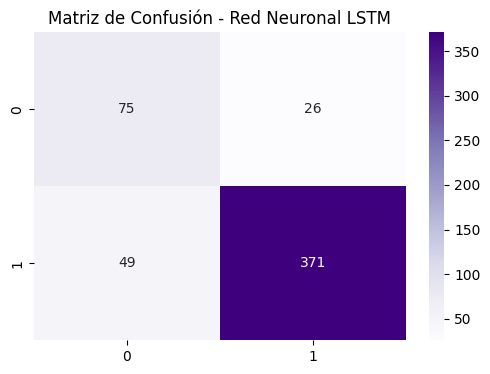

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import classification_report

# ==========================================
# 1. PREPARACIÓN DE SECUENCIAS PARA LSTM
# ==========================================
# Las redes LSTM necesitan ver el pasado. Vamos a crear ventanas
# de tiempo de 3 meses para predecir si el cuarto mes lloverá.

def crear_secuencias(datos, objetivo, ventana=3):
    X_seq, y_seq = [], []
    for i in range(len(datos) - ventana):
        X_seq.append(datos[i:(i + ventana)])
        y_seq.append(objetivo.iloc[i + ventana])
    return np.array(X_seq), np.array(y_seq)

# Generamos las secuencias usando los datos escalados de la celda anterior
ventana = 3
X_train_lstm, y_train_lstm = crear_secuencias(X_train_scaled, y_train, ventana)
X_test_lstm, y_test_lstm = crear_secuencias(X_test_scaled, y_test, ventana)

print(f"Estructura de datos para LSTM: {X_train_lstm.shape}") # (Muestras, Meses, Variables)

# ==========================================
# 2. DEFINICIÓN DE LA RED NEURONAL
# ==========================================
model_lstm = Sequential([
    # Capa de memoria (LSTM) con 50 neuronas
    LSTM(50, activation='relu', input_shape=(ventana, X_train_scaled.shape[1])),
    Dropout(0.2), # Ayuda a evitar que el modelo se "memorice" los datos (overfitting)
    # Capa de salida (1 neurona para clasificación binaria)
    Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ==========================================
# 3. ENTRENAMIENTO
# ==========================================
print("\n--- Entrenando Modelo LSTM (Esto puede tardar unos segundos) ---")
history = model_lstm.fit(
    X_train_lstm, y_train_lstm,
    epochs=40,
    batch_size=16,
    validation_split=0.1,
    verbose=0 # No mostrar cada época para no llenar la pantalla
)

# ==========================================
# 4. EVALUACIÓN FINAL
# ==========================================
# Predicciones
probs_lstm = model_lstm.predict(X_test_lstm)
preds_lstm = (probs_lstm > 0.5).astype(int)

# Cálculo de métricas
acc_l = accuracy_score(y_test_lstm, preds_lstm)
f1_l = f1_score(y_test_lstm, preds_lstm)
auc_l = roc_auc_score(y_test_lstm, probs_lstm)

# Agregar a nuestra tabla de resultados global
resultados_ml.append({
    'Modelo': 'LSTM (Deep Learning)',
    'Accuracy': acc_l,
    'F1-Score': f1_l,
    'AUC-ROC': auc_l
})

print(f"\n✅ LSTM Finalizado. F1-Score obtenido: {f1_l:.4f}")

# MATRIZ DE CONFUSIÓN LSTM
plt.figure(figsize=(6, 4))
cm_lstm = confusion_matrix(y_test_lstm, preds_lstm)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Purples')
plt.title('Matriz de Confusión - Red Neuronal LSTM')
plt.show()

/tmp/ipython-input-165/1297937942.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='F1-Score', data=df_final.sort_values('F1-Score', ascending=False), palette='rocket')


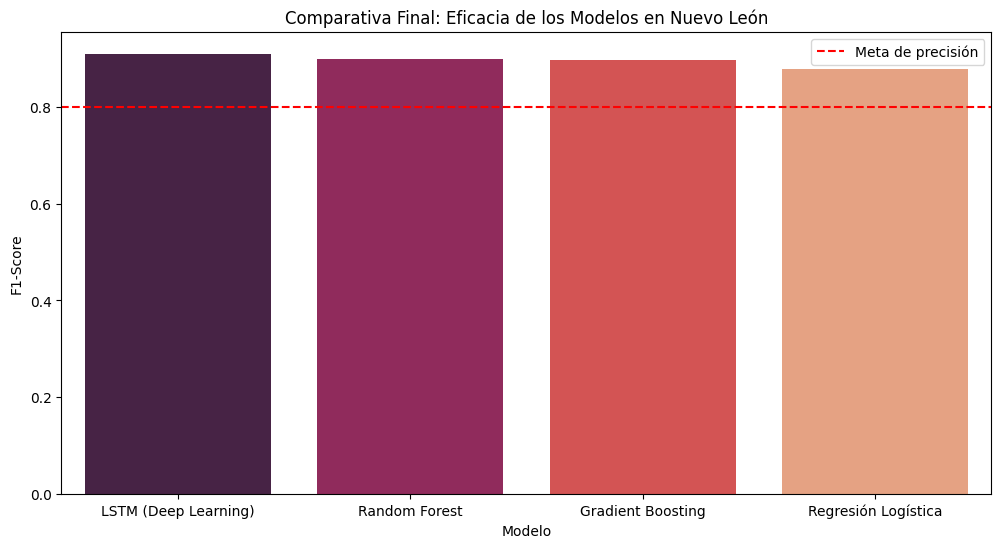


TABLA DE MÉTRICAS FINALES


,Modelo,Accuracy,F1-Score,AUC-ROC
0,Regresión Logística,0.795802,0.876870,0.834356
1,Random Forest,0.828244,0.897494,0.838479
2,Gradient Boosting,0.828244,0.895349,0.847900
3,LSTM (Deep Learning),0.856046,0.908201,0.909359


In [17]:
# Convertimos todos los resultados a un DataFrame final
df_final = pd.DataFrame(resultados_ml)

# Gráfico comparativo de F1-Score
plt.figure(figsize=(12, 6))
sns.barplot(x='Modelo', y='F1-Score', data=df_final.sort_values('F1-Score', ascending=False), palette='rocket')
plt.title('Comparativa Final: Eficacia de los Modelos en Nuevo León')
plt.axhline(0.8, color='red', linestyle='--', label='Meta de precisión')
plt.legend()
plt.show()

# Mostrar tabla final para copiar a Word
print("\nTABLA DE MÉTRICAS FINALES")
display(df_final)